# prepare scanvi reference

In [1]:
from pathlib import Path
import os
import scanpy as sc
from scipy.sparse import issparse
import scvi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import anndata as ad
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


In [3]:
base_dir = Path("/home/workspace/private/projects/kim/drg")
data_dir = base_dir / "data" / "scrna-seq"
input_dir = data_dir / "h5ad" / "04_clustered"

scvi_dir = base_dir / 'scvi/models'

output_dir = '/home/workspace/private/projects/kim/drg/data/scrna-seq/h5ad/05_reference'

In [4]:
adata_1 = sc.read_h5ad(os.path.join(input_dir, "GSE139088-scvi-leiden.h5ad"))
adata_2 = sc.read_h5ad(os.path.join(input_dir, "GSE254789-nonneurons.h5ad"))

adata_list = [adata_1, adata_2]

In [5]:
for data in adata_list:
    data.X = data.layers['counts'].copy()

In [6]:
adata = ad.concat(adata_list, 
                  join="outer", 
                  label = 'batch', # suffix of adata.obs_names should match batch
                  index_unique="-")

In [7]:
adata.obs["cell_label"] = np.where(
    adata.obs["batch"].astype(int) == 0,
    adata.obs["original_annotation"].astype(str).values,
    adata.obs["cell_type"].astype(str).values
)

In [8]:
adata.obs.cell_label.value_counts()

cell_label
SGC                           15210
Vascular_endothelial_1         5007
Schwann_cell                   2699
Nonpeptidergic nociceptors     2669
CGRP-Alpha                     1440
C-LTMR                         1415
CGRP-Epsilion                   848
Sst                             757
CGRP-Theta                      735
CGRP-Gamma                      696
Pericyte                        605
TrpM8                           485
Vascular_endothelial_2          429
Macrophage_1                    405
Cycling SGC                     340
CGRP-Zeta                       321
Fibroblast_1                    282
Abeta-RA-LTMR                   265
CGRP-Eta                        257
Abeta-Field                     245
Proprioceptors                  228
Fibroblast_2                    207
Angiogenic EC                   182
Adelta-LTMR                     153
Macrophage_2                    146
CGRP-Beta                       134
Unknown                          81
Name: count, dtyp

## Prepare adata

In [9]:
adata.X[:5, :5].toarray()

array([[0., 4., 0., 0., 2.],
       [2., 2., 1., 1., 2.],
       [0., 2., 1., 0., 0.],
       [3., 1., 0., 0., 2.],
       [2., 3., 0., 0., 4.]])

In [10]:
# Save counts layer for scVI and downstream processing
adata.X = adata.layers["counts"].copy()

print('adata.X is sparse:', issparse(adata.X))
print('adata.X has only whole numbers:', np.all(adata.X.data == np.round(adata.X.data)))  # True if all values are whole numbers

adata.X is sparse: True
adata.X has only whole numbers: True


In [11]:
adata.X[:5, :5].toarray()

array([[0., 4., 0., 0., 2.],
       [2., 2., 1., 1., 2.],
       [0., 2., 1., 0., 0.],
       [3., 1., 0., 0., 2.],
       [2., 3., 0., 0., 4.]])

## scVI

#### Train model

In [12]:
# Set up AnnData for SCVI
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="counts",  # Use raw count data
    batch_key = 'batch'
)

/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [13]:
# Initialize model
model = scvi.model.SCVI(
    adata,
    gene_likelihood = "zinb" # zero inflated to account for different modalities
)

In [14]:
# Train SCVI with default settings
model.train(accelerator = 'gpu', early_stopping = True)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a

Epoch 221/221: 100%|██████████| 221/221 [40:17<00:00, 10.37s/it, v_num=1, train_loss_step=5.06e+3, train_loss_epoch=5.49e+3]

`Trainer.fit` stopped: `max_epochs=221` reached.


Epoch 221/221: 100%|██████████| 221/221 [40:17<00:00, 10.94s/it, v_num=1, train_loss_step=5.06e+3, train_loss_epoch=5.49e+3]


In [15]:
model.save(scvi_dir, prefix='GSE139088_GSE254789_')

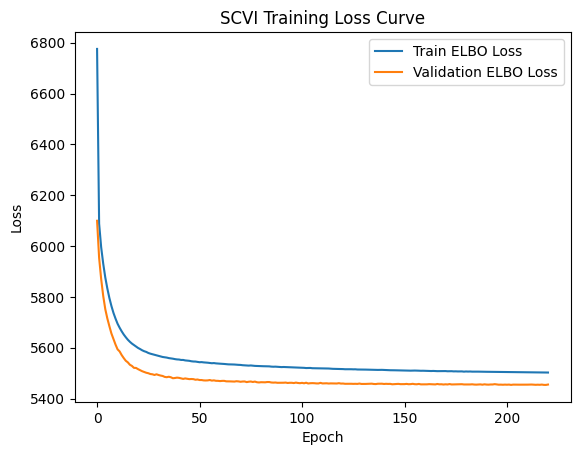

In [16]:
plt.plot(model.history["elbo_train"], label="Train ELBO Loss")
plt.plot(model.history["elbo_validation"], label="Validation ELBO Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("SCVI Training Loss Curve")
plt.show()

## Extract latent representation, save

In [17]:
# add scVI latent dimensions to adata.obsm
adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)
adata.obsm['X_scVI'].shape

(36241, 10)

In [18]:
sc.pp.neighbors(adata, use_rep = 'X_scVI', random_state = 0)
sc.tl.umap(adata, random_state = 0)

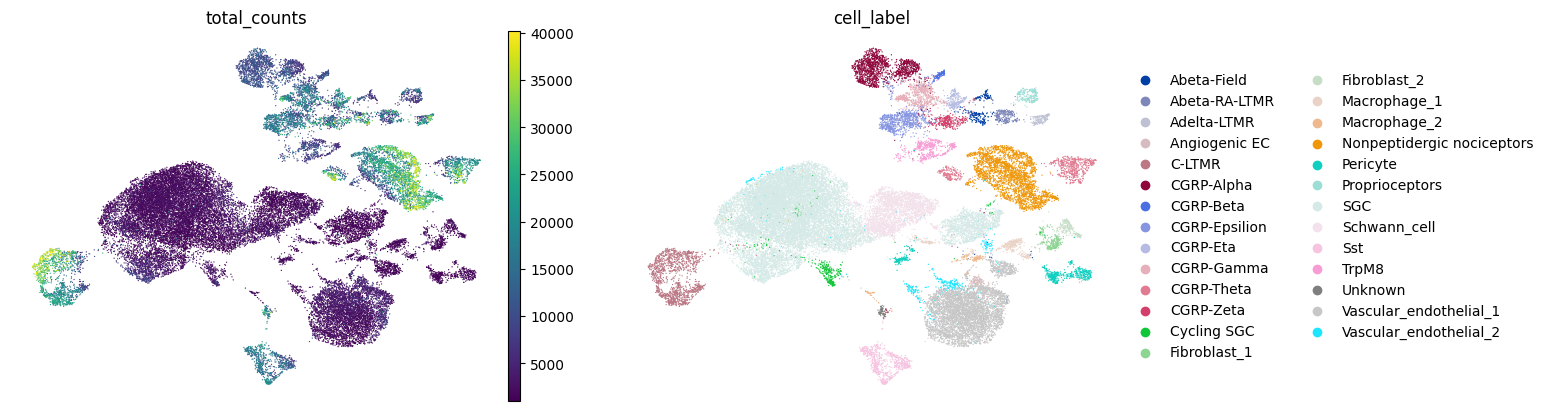

In [21]:
sc.pl.umap(adata, color=['total_counts', 'cell_label'], legend_fontsize=10, frameon=False)

## Export

In [24]:
adata.obs["sample_number"] = adata.obs["sample_number"].astype(str)

In [25]:
#output_dir = '/home/workspace/private/projects/kim/drg/data/scrna-seq/h5ad/05_reference'
filename = os.path.join(output_dir, 'adata-reference.h5ad') # saved with raw layer active
os.makedirs(os.path.dirname(filename), exist_ok=True)

adata.write_h5ad(filename, compression='gzip')

In [30]:
print(filename)

/home/workspace/private/projects/kim/drg/data/scrna-seq/h5ad/05_reference/adata-reference.h5ad


## Session info

In [26]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [29]:
adata.obs

,original_annotation,GSE,GSM,sample_number,sample_id,experiment_id,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,...,doublet_scores,predicted_doublets,_scvi_batch,_scvi_labels,leiden,artifact,class,cell_type,batch,cell_label
GSM4130750_AAACCTGTCTGCTGCT-1-0,CGRP-Theta,GSE139088,GSM4130750,1,GSE139088_1,GSE139088,2523,6931.0,134.0,1.933343,...,0.070248,False,0,0,5,NaN,NaN,NaN,0,CGRP-Theta
GSM4130750_AAACGGGAGTACGCGA-1-0,CGRP-Gamma,GSE139088,GSM4130750,1,GSE139088_1,GSE139088,5212,19993.0,430.0,2.150753,...,0.044776,False,0,0,9,NaN,NaN,NaN,0,CGRP-Gamma
GSM4130750_AAACGGGCAGGGATTG-1-0,CGRP-Alpha,GSE139088,GSM4130750,1,GSE139088_1,GSE139088,4349,13737.0,576.0,4.193055,...,0.025710,False,0,0,0,NaN,NaN,NaN,0,CGRP-Alpha
GSM4130750_AAACGGGCATTGCGGC-1-0,CGRP-Alpha,GSE139088,GSM4130750,1,GSE139088_1,GSE139088,4747,18238.0,490.0,2.686698,...,0.036697,False,0,0,0,NaN,NaN,NaN,0,CGRP-Alpha
GSM4130750_AAACGGGGTGGGTATG-1-0,Nonpeptidergic nociceptors,GSE139088,GSM4130750,1,GSE139088_1,GSE139088,4670,20604.0,514.0,2.494661,...,0.036697,False,0,0,4,NaN,NaN,NaN,0,Nonpeptidergic nociceptors
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM8057829_TTTGGAGAGTCGGGAT-1-1,NaN,GSE254789,GSM8057829,6,GSE254789_6,GSE254789,922,1288.0,37.0,2.872671,...,0.067857,False,1,0,2,OK,Non-neuron,SGC,1,SGC
GSM8057829_TTTGGAGTCCAAACCA-1-1,NaN,GSE254789,GSM8057829,6,GSE254789_6,GSE254789,921,1442.0,114.0,7.905687,...,0.021518,False,1,0,4,OK,Non-neuron,SGC,1,SGC
GSM8057829_TTTGGTTTCCAACCGG-1-1,NaN,GSE254789,GSM8057829,6,GSE254789_6,GSE254789,779,1209.0,48.0,3.970223,...,0.062340,False,1,0,4,OK,Non-neuron,SGC,1,SGC
GSM8057829_TTTGTTGTCCCTTTGG-1-1,NaN,GSE254789,GSM8057829,6,GSE254789_6,GSE254789,786,1235.0,72.0,5.829959,...,0.036145,False,1,0,2,OK,Non-neuron,SGC,1,SGC
